滤波器系数 (SOS):
[[0.00436149 0.00862519 0.00436149 1.         0.43091312 0.05170011]
 [1.         1.81155182 1.         1.         0.39923318 0.08632902]
 [1.         1.53862922 1.         1.         0.34107482 0.15308354]
 [1.         1.23589441 1.         1.         0.26546448 0.24805334]
 [1.         0.96164542 1.         1.         0.18325916 0.36764841]
 [1.         0.74658566 1.         1.         0.10549697 0.5104234 ]
 [1.         0.60197544 1.         1.         0.04272175 0.67881545]
 [1.         0.52988765 1.         1.         0.00549745 0.88114801]]


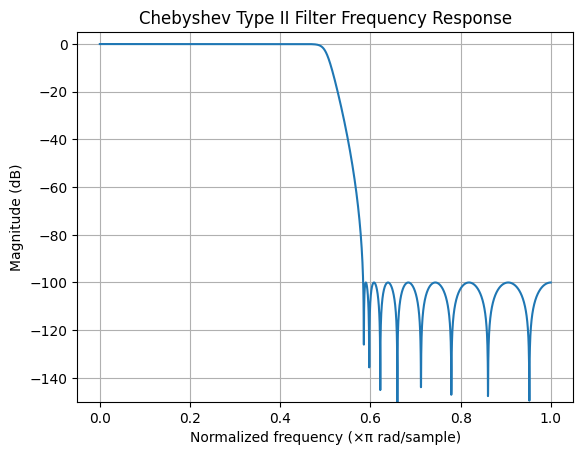

In [52]:
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt

# 32阶切比雪夫2型低通滤波器
order = 16          # 阶数
rs = 100            # 阻带衰减 (dB)
atten = 3           # 1rad/s处的衰减(0.5采样率相当于pi/2)

if atten >= rs:
    raise RuntimeError('atten < ripple')

fscale = np.cosh(np.acosh(np.sqrt((np.pow(10.0, rs / 10.0) - 1.0) / (np.pow(10.0, atten / 10.0) - 1.0))) / (order))
w = np.atan(fscale) / (2 * np.pi)

# 使用二阶节形式 (sos) 保证数值稳定性
sos = signal.cheby2(order, rs, w, fs=0.5, output='sos')

print("滤波器系数 (SOS):")
print(sos)

# 频率响应
w, h = signal.sosfreqz(sos, worN=4096)
plt.figure()
plt.plot(w / np.pi, 20 * np.log10(np.abs(h)))
plt.title("Chebyshev Type II Filter Frequency Response")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-150, 5)
plt.show()

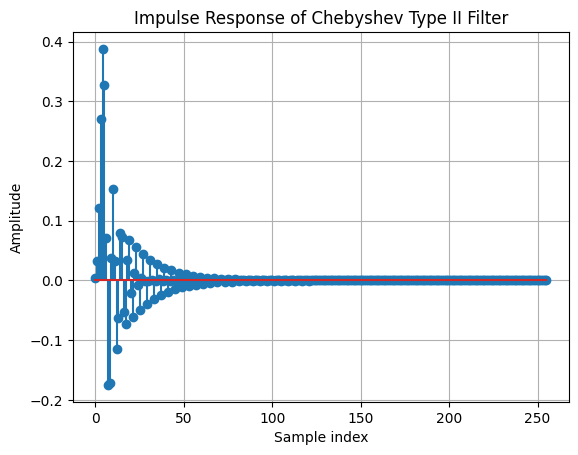

In [53]:
# Generate impulse and filter
n_samples = 256  # choose a sufficient length to capture the response
impulse = np.zeros(n_samples)
impulse[0] = 1.0
impulse_response = signal.sosfilt(sos, impulse)

# Plot
plt.figure()
plt.stem(impulse_response)
plt.title("Impulse Response of Chebyshev Type II Filter")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Partial fraction expansion (parallel form):
Residues (r):
 [-1.19535878e+02-37.26856867j -1.19535878e+02+37.26856867j
 -4.12825925e+01-73.7216676j  -4.12825925e+01+73.7216676j
  2.10701395e+01-42.98974571j  2.10701395e+01+42.98974571j
  2.41314785e+01 -0.61616803j  2.41314785e+01 +0.61616803j
  4.39931393e+00 +9.53522737j  4.39931393e+00 -9.53522737j
 -2.61221472e+00 +2.61234216j -2.61221472e+00 -2.61234216j
 -8.32750721e-01 -0.43248934j -8.32750721e-01 +0.43248934j
  2.91866858e-02 -0.12702498j  2.91866858e-02 +0.12702498j]

Poles (p):
 [-0.21545656-0.07265382j -0.21545656+0.07265382j -0.19961659-0.2155974j
 -0.19961659+0.2155974j  -0.17053741-0.35213709j -0.17053741+0.35213709j
 -0.13273224-0.48003697j -0.13273224+0.48003697j -0.09162958-0.5993767j
 -0.09162958+0.5993767j  -0.05274848-0.71248929j -0.05274848+0.71248929j
 -0.02136088-0.82362562j -0.02136088+0.82362562j -0.00274872-0.93869082j
 -0.00274872+0.93869082j]

Direct term:
 [229.2709967]


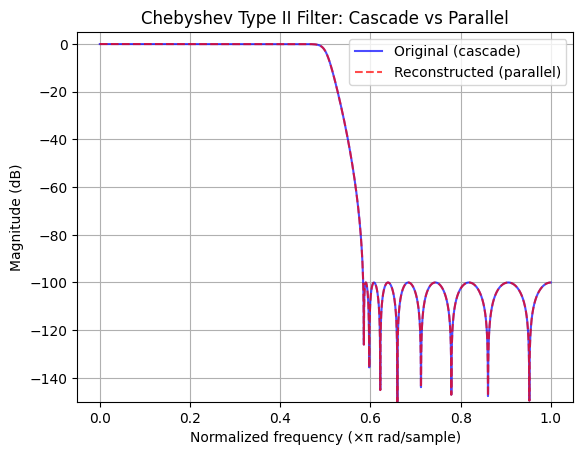

In [54]:
# Convert cascade (series) filter to parallel form using partial fraction expansion
# First, convert SOS to transfer function polynomials
b, a = signal.sos2tf(sos)

# Compute residues, poles, and direct term
residues, poles, direct_term = signal.residuez(b, a)

# Print the results
print("Partial fraction expansion (parallel form):")
print("Residues (r):\n", residues)
print("\nPoles (p):\n", poles)
print("\nDirect term:\n", direct_term)

# Verify the parallel form by reconstructing frequency response
# Use the same frequency points w from the original plot
z = np.exp(1j * w)
H_parallel = direct_term * np.ones_like(z)
for r, p in zip(residues, poles):
    H_parallel += r / (1 - p * z**-1)

# Plot comparison of original and parallel frequency responses
plt.figure()
plt.plot(w / np.pi, 20 * np.log10(np.abs(h)), 'b-', label='Original (cascade)', alpha=0.7)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H_parallel)), 'r--', label='Reconstructed (parallel)', alpha=0.7)
plt.title("Chebyshev Type II Filter: Cascade vs Parallel")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid()
plt.ylim(-150, 5)
plt.show()

In [55]:
a = []
b = []
c = []
d = []

for i in range(0, len(residues), 2):
    p = poles[i]
    pdot = poles[i + 1]
    r = residues[i]
    rdot = residues[i + 1]

    a.append(np.real(r + rdot))
    b.append(np.real(r * pdot + rdot * p))
    c.append(np.real(p + pdot))
    d.append(np.real(p * pdot))

# Print a, b, c, d as C float arrays
for name, arr in [('a', a), ('b', b), ('c', c), ('d', d)]:
    print(f"static constexpr float {name}[{len(arr)}]{{")
    elements = ", ".join(f"{v:.10e}f" for v in arr)
    print("    " + elements + "};")
    print()


static constexpr float a[8]{
    -2.3907175666e+02f, -8.2565184991e+01f, 4.2140279038e+01f, 4.8262957055e+01f, 8.7986278635e+00f, -5.2244294420e+00f, -1.6655014413e+00f, 5.8373371598e-02f};

static constexpr float b[8]{
    5.6924986659e+01f, 4.8269780980e+01f, 2.3090074198e+01f, -5.8144834213e+00f, -1.2236600752e+01f, -3.4469509136e+00f, 7.4799516590e-01f, 2.3831392174e-01f};

static constexpr float c[8]{
    -4.3091312308e-01f, -3.9923317942e-01f, -3.4107482346e-01f, -2.6546447571e-01f, -1.8325915687e-01f, -1.0549696976e-01f, -4.2721753637e-02f, -5.4974465931e-03f};

static constexpr float d[8]{
    5.1700107953e-02f, 8.6329023551e-02f, 1.5308354230e-01f, 2.4805334332e-01f, 3.6764840562e-01f, 5.1042339746e-01f, 6.7881544631e-01f, 8.8114801219e-01f};

